## Student Performance Indicator


#### Life cycle of Machine learning Project

- Understanding the Problem Statement
- Data Collection
- Data Checks to perform
- Exploratory data analysis
- Data Pre-Processing
- Model Training
- Choose best model

### 1) Problem statement
- This project understands how the student's performance (test scores) is affected by other variables such as Gender, Ethnicity, Parental level of education, Lunch and Test preparation course.


### 2) Data Collection
- Dataset Source - [Kaggle](https://www.kaggle.com/datasets/spscientist/students-performance-in-exams?datasetId=74977)
- The data consists of 8 column and 1000 rows.

### 2.1 Import Data and Required Packages
####  Importing Pandas, Numpy, Matplotlib, Seaborn and Warings Library.

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

#### Import the CSV Data as Pandas DataFrame

In [2]:
df = pd.read_csv('data/stud.csv')

#### Show Top 5 Records

In [3]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


#### Shape of the dataset

In [4]:
df.shape

(1000, 8)

### 2.2 Dataset information

- `gender` : sex of students  -> (Male/female)
- `race/ethnicity` : ethnicity of students -> (Group A, B,C, D,E)
- `parental level of education` : parents' final education ->(bachelor's degree,some college,master's degree,associate's degree,high school)
- `lunch` : having lunch before test (standard or free/reduced) 
- `test preparation course` : complete or not complete before test
- `math score`
- `reading score`
- `writing score`

### 3. Data Checks to perform

- Check Missing values
- Check Duplicates
- Check data type
- Check the number of unique values of each column
- Check statistics of data set
- Check various categories present in the different categorical column

### 3.1 Check Missing values

In [5]:
df.isna().sum()

gender                         0
race_ethnicity                 0
parental_level_of_education    0
lunch                          0
test_preparation_course        0
math_score                     0
reading_score                  0
writing_score                  0
dtype: int64

#### There are no missing values in the data set

### 3.2 Check Duplicates

In [6]:
df.duplicated().sum()

np.int64(0)

#### There are no duplicates  values in the data set

### 3.3 Check data types

In [7]:
# Check Null and Dtypes
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   gender                       1000 non-null   str  
 1   race_ethnicity               1000 non-null   str  
 2   parental_level_of_education  1000 non-null   str  
 3   lunch                        1000 non-null   str  
 4   test_preparation_course      1000 non-null   str  
 5   math_score                   1000 non-null   int64
 6   reading_score                1000 non-null   int64
 7   writing_score                1000 non-null   int64
dtypes: int64(3), str(5)
memory usage: 62.6 KB


### 3.4 Checking the number of unique values of each column

In [8]:
df.nunique()

gender                          2
race_ethnicity                  5
parental_level_of_education     6
lunch                           2
test_preparation_course         2
math_score                     81
reading_score                  72
writing_score                  77
dtype: int64

### 3.5 Check statistics of data set

In [9]:
df.describe()

,math_score,reading_score,writing_score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


#### Insight
- From above description of numerical data, all means are very close to each other - between 66 and 68.05;
- All standard deviations are also close - between 14.6 and 15.19;
- While there is a minimum score  0 for math, for writing minimum is much higher = 10 and for reading much higher = 17

### 3.7 Exploring Data

In [10]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [11]:
print(f"Categories in 'gender' variable: {df['gender'].unique().tolist()}")
print(f"Categories in 'race_ethnicity' variable: {df['race_ethnicity'].unique().tolist()}")
print(f"Categories in'parental level of education' variable: {df['parental_level_of_education'].unique().tolist()}" )
print(f"Categories in 'lunch' variable: {df['lunch'].unique().tolist()}")
print(f"Categories in 'test preparation course' variable: {df['test_preparation_course'].unique().tolist()}")

Categories in 'gender' variable: ['female', 'male']
Categories in 'race_ethnicity' variable: ['group B', 'group C', 'group A', 'group D', 'group E']
Categories in'parental level of education' variable: ["bachelor's degree", 'some college', "master's degree", "associate's degree", 'high school', 'some high school']
Categories in 'lunch' variable: ['standard', 'free/reduced']
Categories in 'test preparation course' variable: ['none', 'completed']


In [12]:
# define numerical & categorical columns
numeric_features = [feature for feature in df.columns if df[feature].dtype != 'str']
categorical_features = [feature for feature in df.columns if df[feature].dtype == 'str']

# print columns
print('We have {} numerical features : {}'.format(len(numeric_features), numeric_features))
print('\nWe have {} categorical features : {}'.format(len(categorical_features), categorical_features))

We have 3 numerical features : ['math_score', 'reading_score', 'writing_score']

We have 5 categorical features : ['gender', 'race_ethnicity', 'parental_level_of_education', 'lunch', 'test_preparation_course']


In [13]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   gender                       1000 non-null   str  
 1   race_ethnicity               1000 non-null   str  
 2   parental_level_of_education  1000 non-null   str  
 3   lunch                        1000 non-null   str  
 4   test_preparation_course      1000 non-null   str  
 5   math_score                   1000 non-null   int64
 6   reading_score                1000 non-null   int64
 7   writing_score                1000 non-null   int64
dtypes: int64(3), str(5)
memory usage: 62.6 KB


In [14]:
df.head(2)

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88


### 3.8 Adding columns for "Total Score" and "Average"

In [15]:
df['tot_score'] = df['math_score'] + df['reading_score'] + df['writing_score']
df['avg_score'] = df['tot_score'] / 3
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,tot_score,avg_score
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333


In [16]:
reading_full = df[df['reading_score'] == 100]['avg_score'].count()
writing_full = df[df['writing_score'] == 100]['avg_score'].count()
math_full = df[df['math_score'] == 100]['avg_score'].count() 

print(f"Number of students with full marks in Maths: {math_full}")
print(f"Number of students with full marks in Writing: {writing_full}")
print(f"Number of students with full marks in Reading: {reading_full}")

Number of students with full marks in Maths: 7
Number of students with full marks in Writing: 14
Number of students with full marks in Reading: 17


In [17]:
reading_less_20 = df[df['reading_score'] <= 20]['avg_score'].count()
writing_less_20 = df[df['writing_score'] <= 20]['avg_score'].count()
math_less_20 = df[df['math_score'] <= 20]['avg_score'].count()

print(f"Number of students with less than 20 marks in Maths: {math_less_20}")
print(f"Number of students with less than 20 marks in Writing: {writing_less_20}")
print(f"Number of students with less than 20 marks in Reading: {reading_less_20}")

Number of students with less than 20 marks in Maths: 4
Number of students with less than 20 marks in Writing: 3
Number of students with less than 20 marks in Reading: 1


#####  Insights
 - From above values we get students have performed the worst in Maths 
 - Best performance is in reading section

### 4. Exploring Data ( Visualization )
#### 4.1 Visualize average score distribution to make some conclusion. 
- Histogram
- Kernel Distribution Function (KDE)

#### 4.1.1 Histogram & KDE

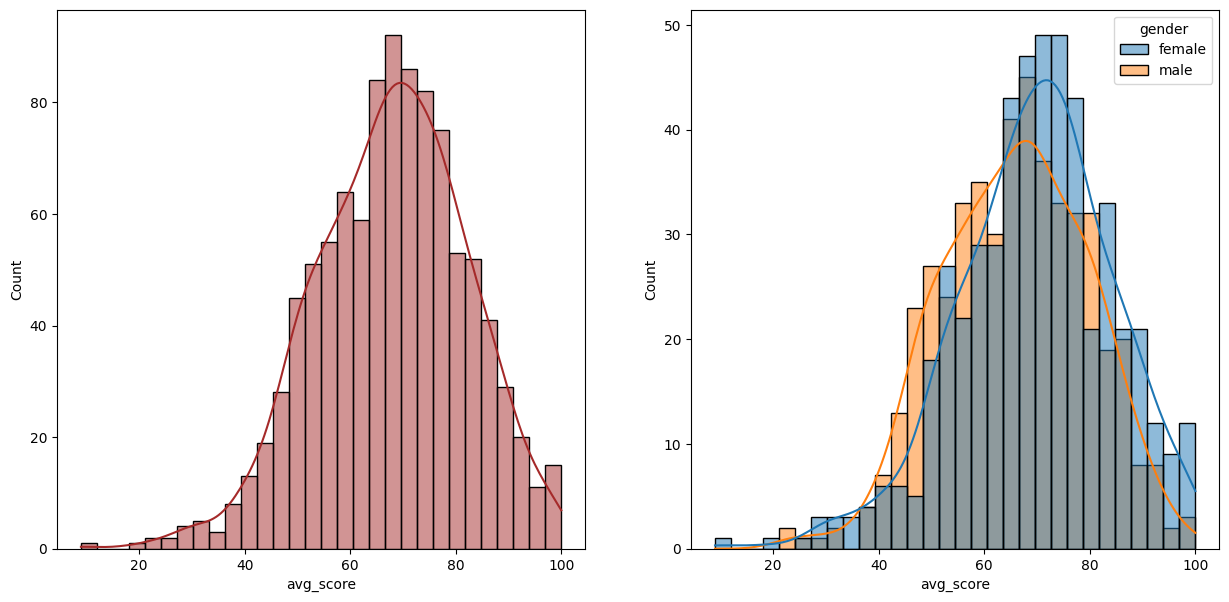

In [18]:
# Normal way
fig, axs = plt.subplots(1,2, figsize=(15,7))
plt.subplot(121)
sns.histplot(data=df, x='avg_score', bins=30, kde=True, color='brown')
plt.subplot(122)
sns.histplot(data=df, x='avg_score', bins=30, kde=True, hue='gender')
plt.show()
# Note: the gray color is appeared due to overlapping.

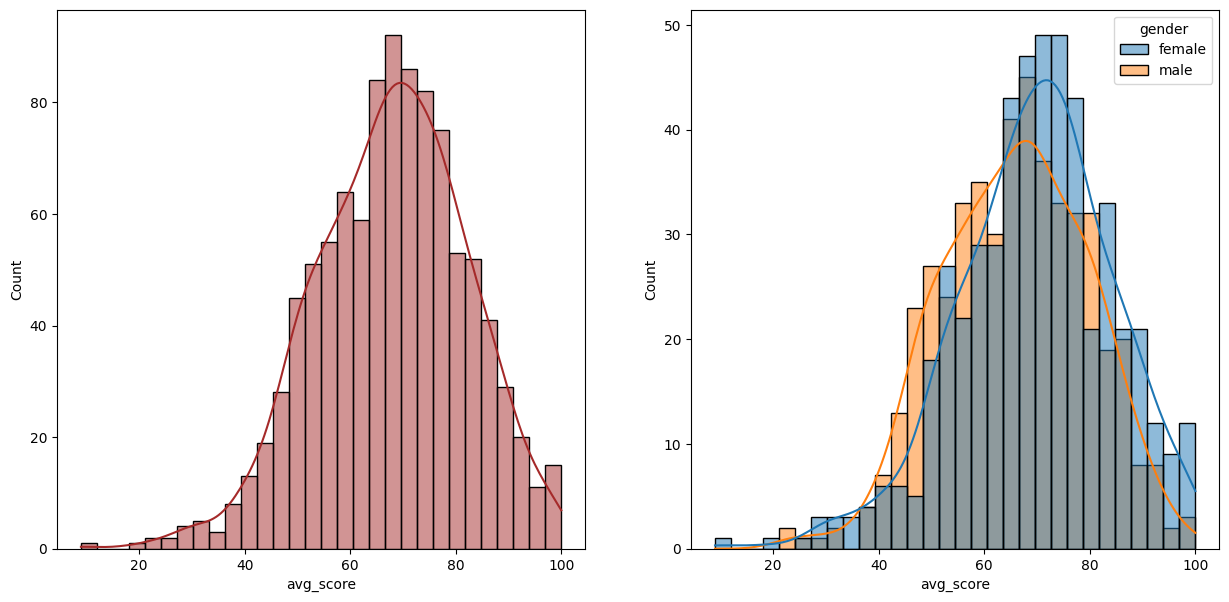

In [19]:
# Shorter way (my recommendation)
fig, axs = plt.subplots(1, 2, figsize=(15,7))
sns.histplot(data=df, x='avg_score', bins=30, kde=True, color='brown', ax=axs[0])
sns.histplot(data=df, x='avg_score', bins=30, kde=True, hue='gender', ax=axs[1])
plt.show()
# Note: the gray color is appeared due to overlapping.

#####  Insights
- Female students tend to perform well then male students.

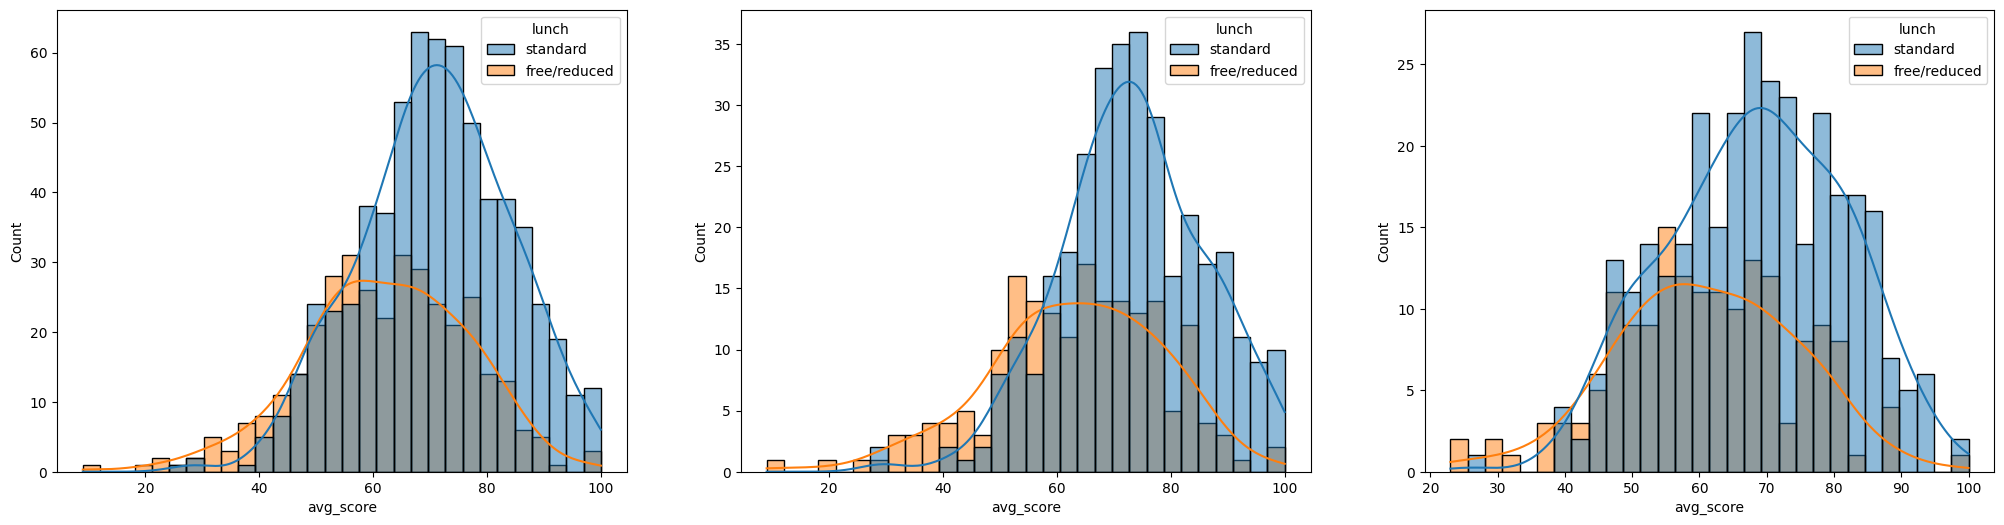

In [20]:
order = ['standard', 'free/reduced']
fig, axs = plt.subplots(1, 3, figsize=(25,6))
sns.histplot(data=df, x='avg_score', bins=30, kde=True, hue='lunch', hue_order= order, ax=axs[0])
sns.histplot(data=df[df.gender == 'female'], x='avg_score', bins=30, kde=True, hue='lunch', hue_order= order, ax=axs[1])
sns.histplot(data=df[df.gender == 'male'], x='avg_score', bins=30, kde=True, hue='lunch', hue_order= order, ax=axs[2])
plt.show()
# Note: the gray color is appeared due to overlapping.

#####  Insights
- Standard lunch helps perform well in exams.
- Standard lunch helps perform well in exams be it a male or a female.

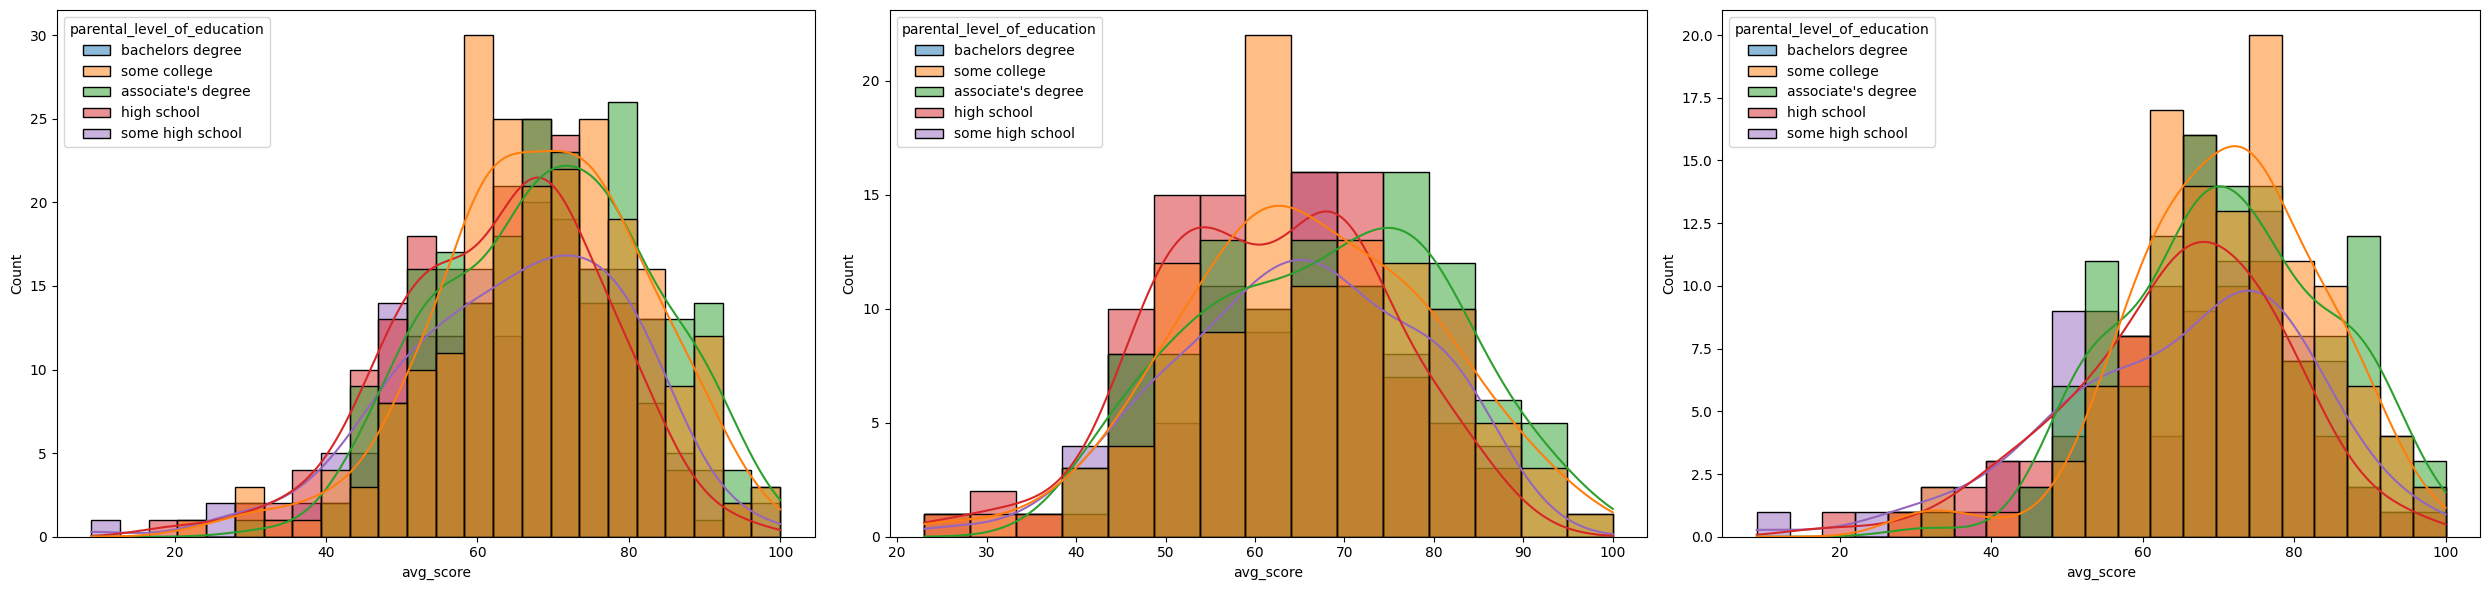

In [21]:
order = ["bachelors degree", "some college", "associate's degree","high school","some high school"]
fig, axs = plt.subplots(1, 3, figsize=(25,6))
sns.histplot(data=df, x='avg_score', kde=True, hue='parental_level_of_education', hue_order=order, ax=axs[0])
sns.histplot(data=df[df.gender=='male'], x='avg_score', kde=True, hue='parental_level_of_education', hue_order=order, ax=axs[1])
sns.histplot(data=df[df.gender=='female'], x='avg_score', kde=True, hue='parental_level_of_education', hue_order=order, ax=axs[2])    

for ax in axs:
    sns.move_legend(ax, "upper left")

plt.tight_layout()
plt.show()

#####  Insights
- In general parent's education don't help student perform well in exam.
- 2nd plot shows that parent's whose education is of associate's degree or master's degree their male child tend to perform well in exam
- 3rd plot we can see there is no effect of parent's education on female students.

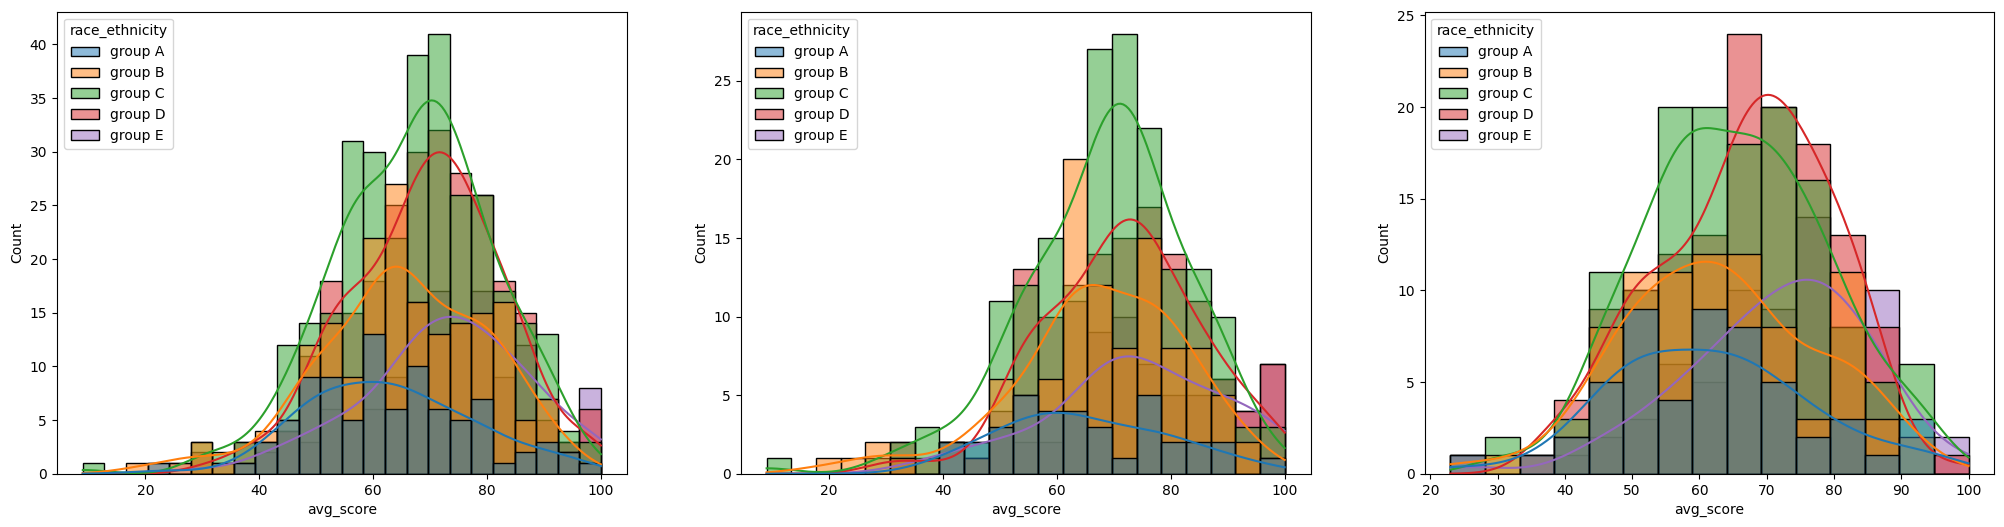

In [22]:
order = ['group A','group B','group C','group D','group E']
fig, axs = plt.subplots(1, 3, figsize=(25,6))
sns.histplot(data=df, x='avg_score', kde=True, hue="race_ethnicity", hue_order=order, ax=axs[0])
sns.histplot(data=df[df.gender=='female'], x='avg_score', kde=True, hue='race_ethnicity', hue_order=order, ax=axs[1])
sns.histplot(data=df[df.gender=='male'], x='avg_score', kde=True, hue='race_ethnicity', hue_order=order, ax=axs[2])

for ax in axs:
    sns.move_legend(ax, "upper left")

plt.show()

#####  Insights
- Students of group A and group B tends to perform poorly in exam.
- Students of group A and group B tends to perform poorly in exam irrespective of whether they are male or female

#### 4.2 Maximumum score of students in all three subjects

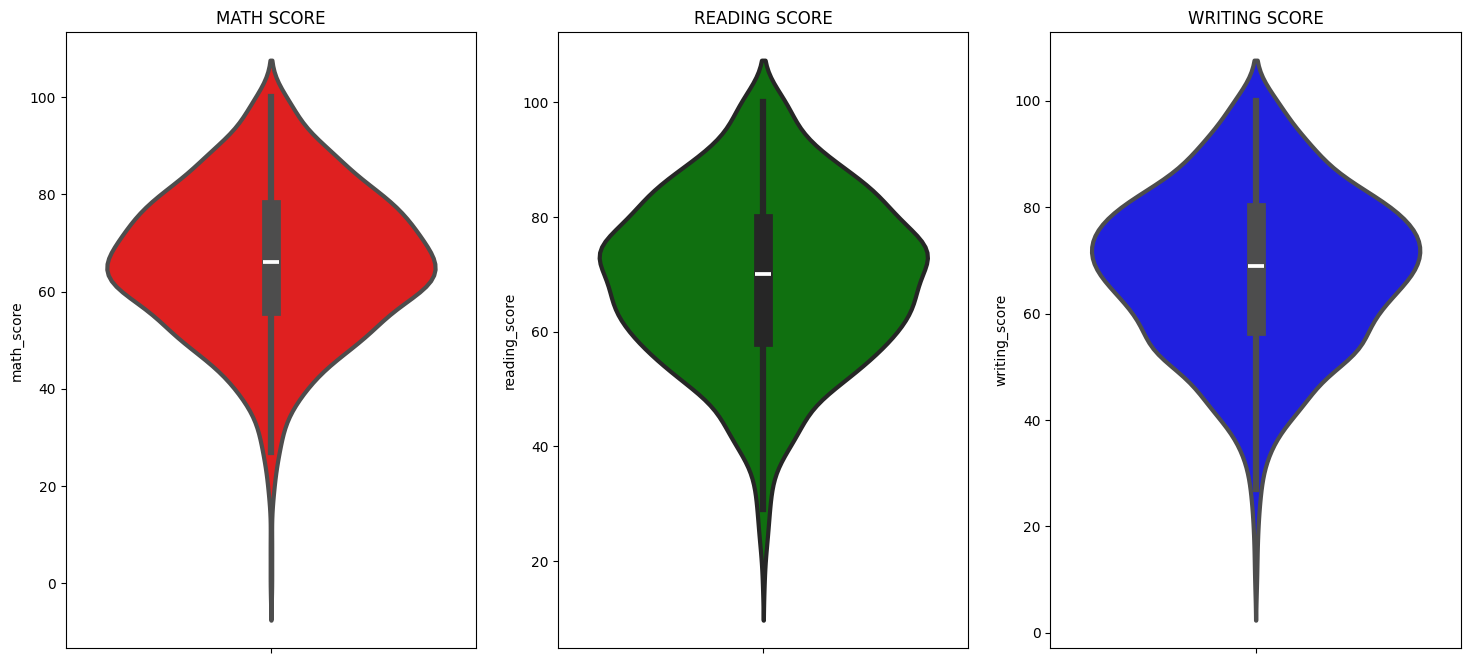

In [23]:
order = ['group A','group B','group C','group D','group E']
fig, axs = plt.subplots(1, 3, figsize=(18,8))

sns.violinplot(data=df, y='math_score', color='red', linewidth=3, ax=axs[0])
sns.violinplot(data=df, y='reading_score', color='green', linewidth=3, ax=axs[1])
sns.violinplot(data=df, y='writing_score', color='blue', linewidth=3, ax=axs[2])

axs[0].set_title("MATH SCORE")
axs[1].set_title("READING SCORE")
axs[2].set_title("WRITING SCORE")

plt.show()

#### Insights
- From the above three plots its clearly visible that most of the students score in between 60-80 in Maths whereas in reading and writing most of them score from 50-80

#### 4.3 Multivariate analysis using pieplot

In [24]:
df.head(2)

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,tot_score,avg_score
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333


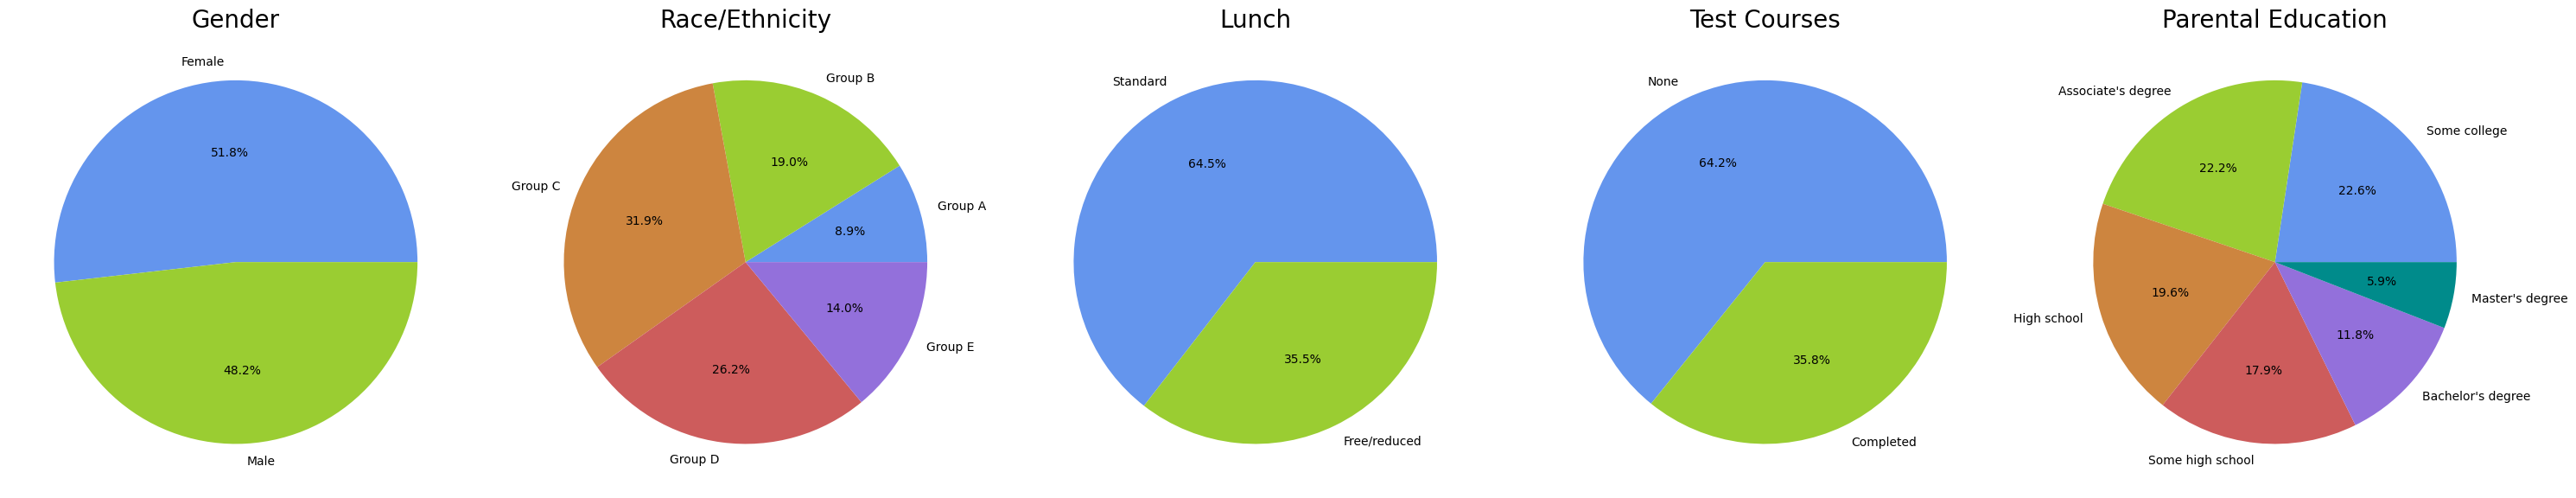

In [25]:
def visualize(size, colors, labels, title):
    plt.pie(size, colors=colors, labels=labels, autopct='%.1f%%')
    plt.title(title, fontsize=20)
    plt.axis('off')


plt.rcParams['figure.figsize'] = (30, 20)

plt.subplot(1,5,1)
size = df['gender'].value_counts(normalize=True)
labels = 'Female', 'Male'
colors = ['cornflowerblue', 'yellowgreen']
visualize(size, colors, labels, title='Gender')

plt.subplot(1,5,2)
size = df['race_ethnicity'].value_counts(normalize=True).sort_index()
labels = 'Group A', 'Group B', 'Group C', 'Group D', 'Group E'
colors = ['cornflowerblue','yellowgreen','peru','indianred','mediumpurple']
visualize(size, colors, labels, title='Race/Ethnicity')

plt.subplot(1,5,3)
size = df['lunch'].value_counts(normalize=True)
labels = "Standard", "Free/reduced"
colors = ['cornflowerblue', 'yellowgreen']
visualize(size, colors, labels,title='Lunch')

plt.subplot(1,5,4)
size = df['test_preparation_course'].value_counts(normalize=True)
labels = "None", "Completed"
colors = ['cornflowerblue', 'yellowgreen']
visualize(size, colors, labels, title='Test Courses')

plt.subplot(1,5,5)
size = df['parental_level_of_education'].value_counts(normalize=True)
labels = "Some college","Associate's degree","High school","Some high school","Bachelor's degree","Master's degree"
colors = ['cornflowerblue','yellowgreen','peru','indianred','mediumpurple','darkcyan']
visualize(size, colors, labels, title='Parental Education')

plt.tight_layout()
plt.grid()
plt.show()

#####  Insights
- Number of Male and Female students is almost equal
- Number students are greatest in Group C
- Number of students who have standard lunch are greater
- Number of students who have not enrolled in any test preparation course is greater
- Number of students whose parental education is "Some College" is greater followed closely by "Associate's Degree"

### 4.4 Feature Wise Visualization
#### 4.4.1 GENDER COLUMN
- How is distribution of Gender ?
- Is gender has any impact on student's performance ?

#### UNIVARIATE ANALYSIS ( How is distribution of Gender ? )

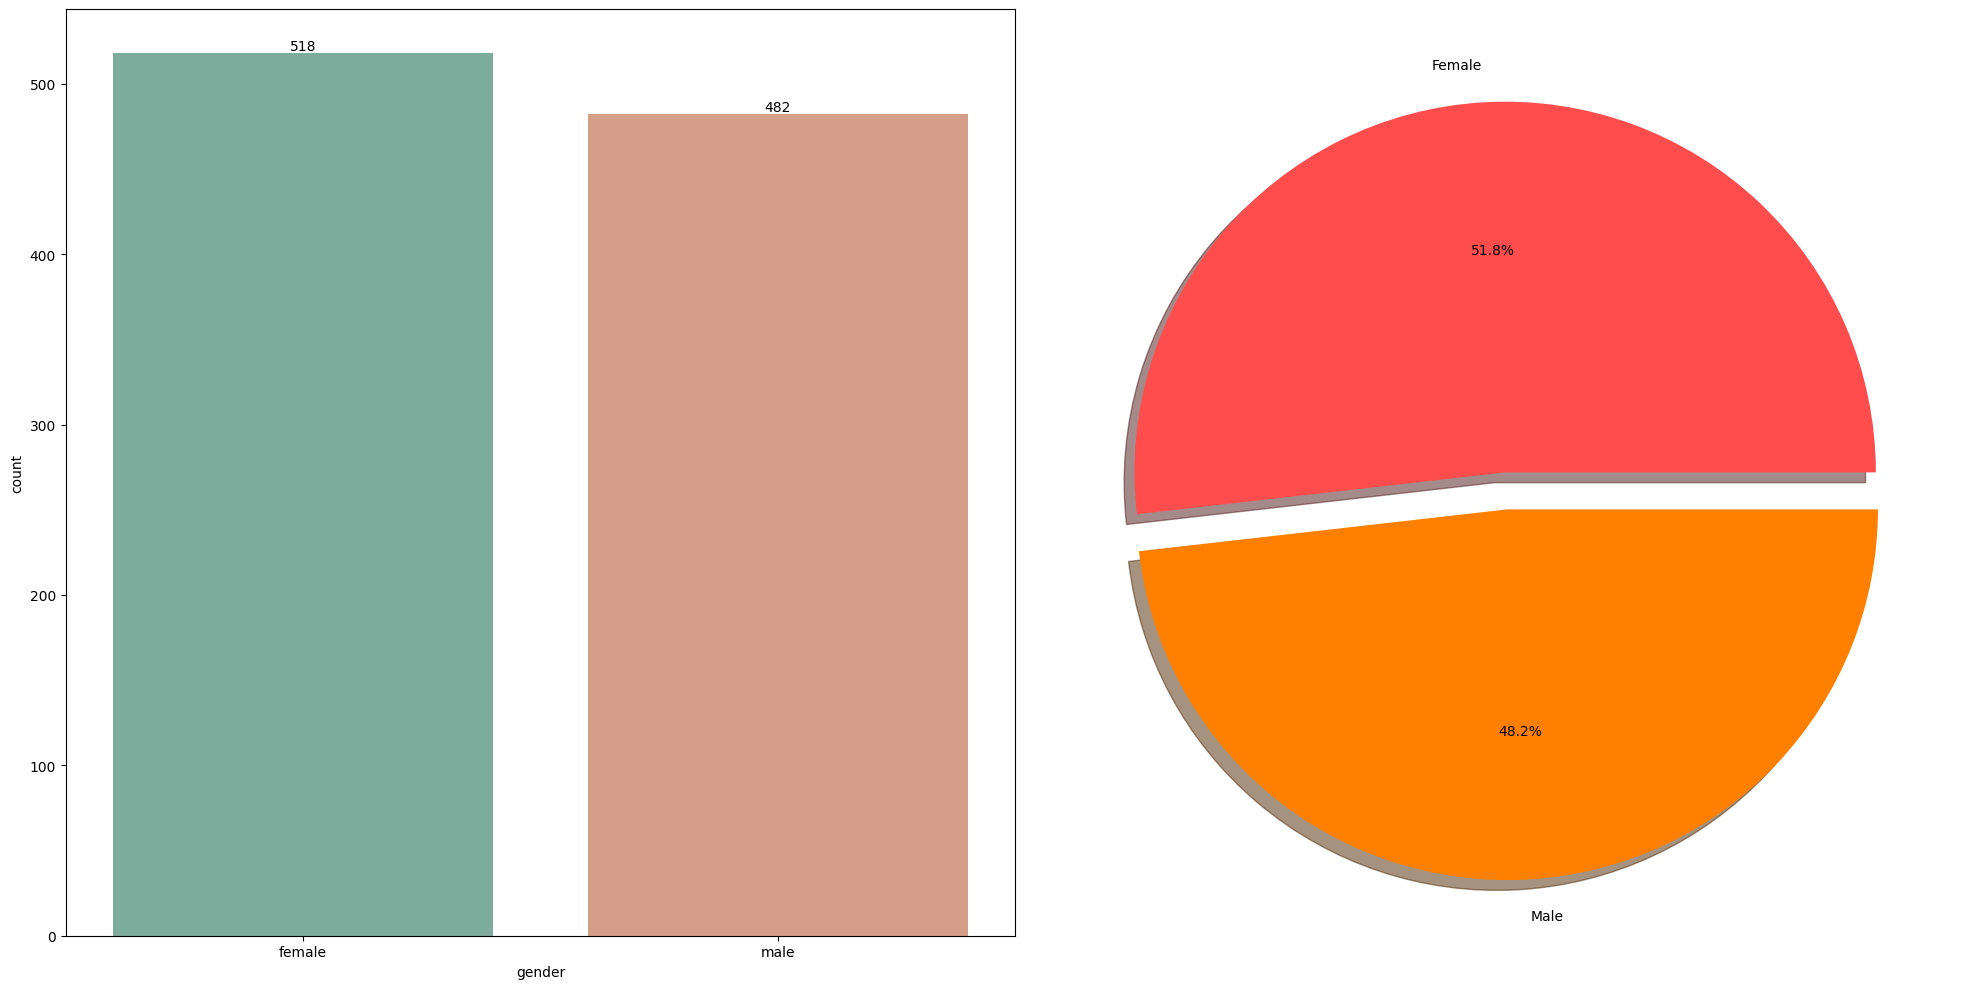

In [26]:
f, ax = plt.subplots(1, 2, figsize=(20,10))
sns.countplot(data=df, x='gender', palette='Set2', ax=ax[0], saturation=.50) # saturation = color intensity
for container in ax[0].containers:
    ax[0].bar_label(container, color='black', size=10)

plt.pie(x=df.gender.value_counts(), 
        labels=['Female','Male'], 
        explode=[0,0.1], 
        autopct='%1.1f%%', 
        shadow=True, 
        colors=['#ff4d4d','#ff8000'])

plt.tight_layout()
plt.show()

#### Insights 
- Gender has balanced data with female students are 518 (48%) and male students are 482 (52%) 

#### BIVARIATE ANALYSIS ( Is gender has any impact on student's performance ? ) 

In [27]:
gender_gp = df.groupby('gender').mean(numeric_only=True)
gender_gp

,math_score,reading_score,writing_score,tot_score,avg_score
gender,,,,,
female,63.633205,72.608108,72.467181,208.708494,69.569498
male,68.728216,65.473029,63.311203,197.512448,65.837483


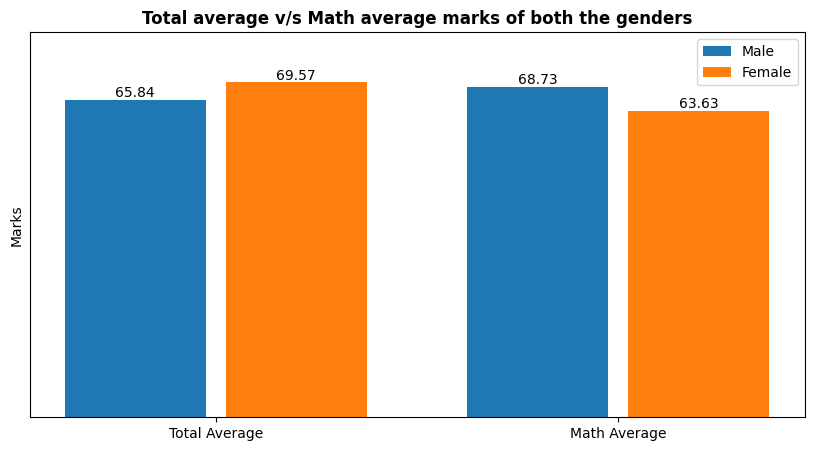

In [28]:
plt.figure(figsize=(10, 5))

X = ['Total Average','Math Average']

female_scores = gender_gp.loc['female','avg_score'], gender_gp.loc['female','math_score']
male_scores = gender_gp.loc['male','avg_score'], gender_gp.loc['male','math_score']

X_axis = np.arange(len(X))

m_bar = plt.bar(X_axis-0.2, male_scores, 0.35, label='Male')
f_bar = plt.bar(X_axis + 0.2, female_scores, 0.35, label='Female')

# Labelling
plt.bar_label(m_bar, fmt='%.2f')
plt.bar_label(f_bar, fmt='%.2f')

plt.ylim(0, 80)
plt.xticks(X_axis, X)
plt.yticks([])
plt.ylabel("Marks")
plt.title("Total average v/s Math average marks of both the genders", fontweight='bold')
plt.legend()
plt.show()

#### Insights 
- On an average females have a better overall score than men.
- whereas males have scored higher in Maths.

#### 4.4.2 RACE/EHNICITY COLUMN
- How is Group wise distribution ?
- Is Race/Ehnicity has any impact on student's performance ?

#### UNIVARIATE ANALYSIS ( How is Group wise distribution ?)

In [29]:
df.race_ethnicity.unique()

<StringArray>
['group B', 'group C', 'group A', 'group D', 'group E']
Length: 5, dtype: str

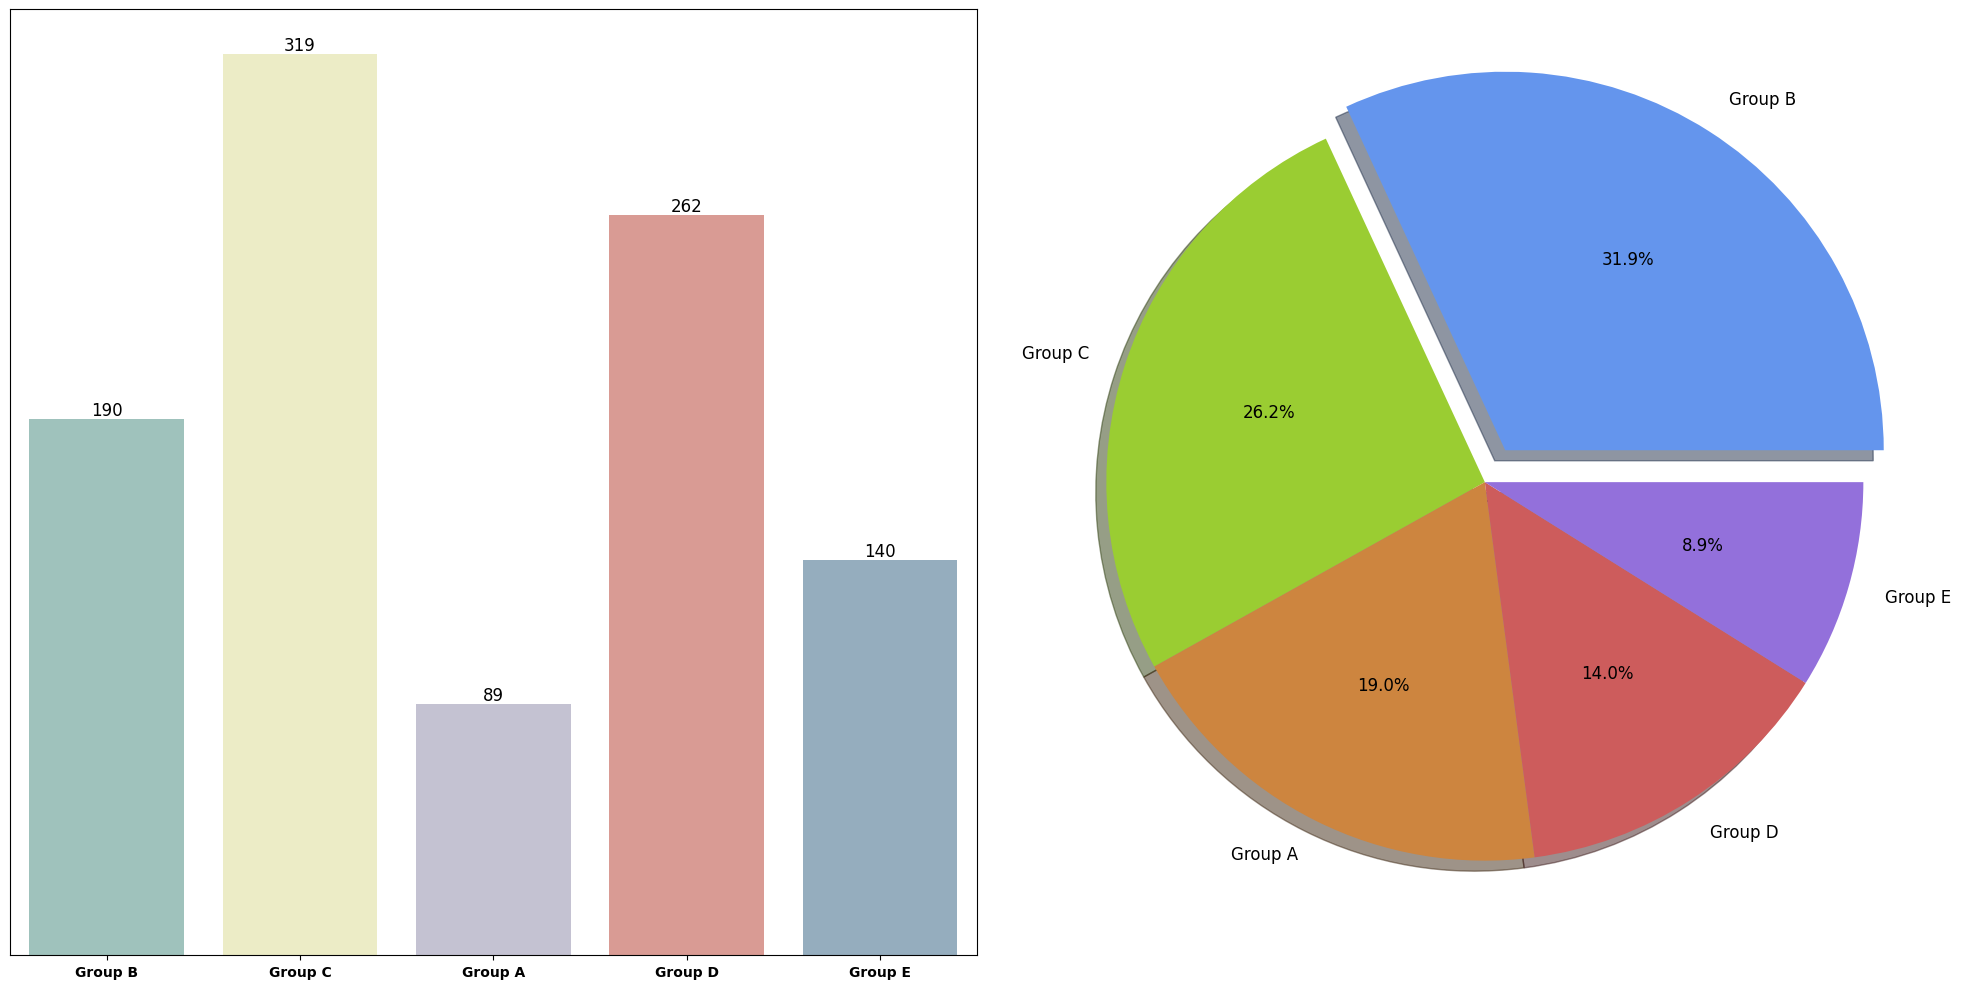

In [30]:
fig, ax = plt.subplots(1, 2, figsize=(20,10))
sns.countplot(data=df, x=df['race_ethnicity'], palette='Set3', ax=ax[0], saturation=0.5)

for container in ax[0].containers:
    ax[0].bar_label(container, size=12)

labels = ['Group B','Group C','Group A','Group D','Group E']
colors = ['cornflowerblue','yellowgreen','peru','indianred','mediumpurple']
plt.pie(df.race_ethnicity.value_counts(), labels=labels, explode=[0.1,0,0,0,0], 
        autopct='%.1f%%', shadow=True, colors=colors, textprops={'size':12})

ax[0].set_yticks([])
ax[0].set_xticks(np.arange(len(labels)), labels, weight='bold')
ax[0].set_xlabel('')
ax[0].set_ylabel('')
plt.tight_layout()
plt.show()

#### Insights 
- Most of the student belonging from group C /group D.
- Lowest number of students belong to groupA.

#### BIVARIATE ANALYSIS ( Is Race/Ehnicity has any impact on student's performance ? )

In [31]:
gp_data = df.groupby('race_ethnicity')
gp_data

In [32]:
gp_data['math_score'].mean()

race_ethnicity
group A    61.629213
group B    63.452632
group C    64.463950
group D    67.362595
group E    73.821429
Name: math_score, dtype: float64

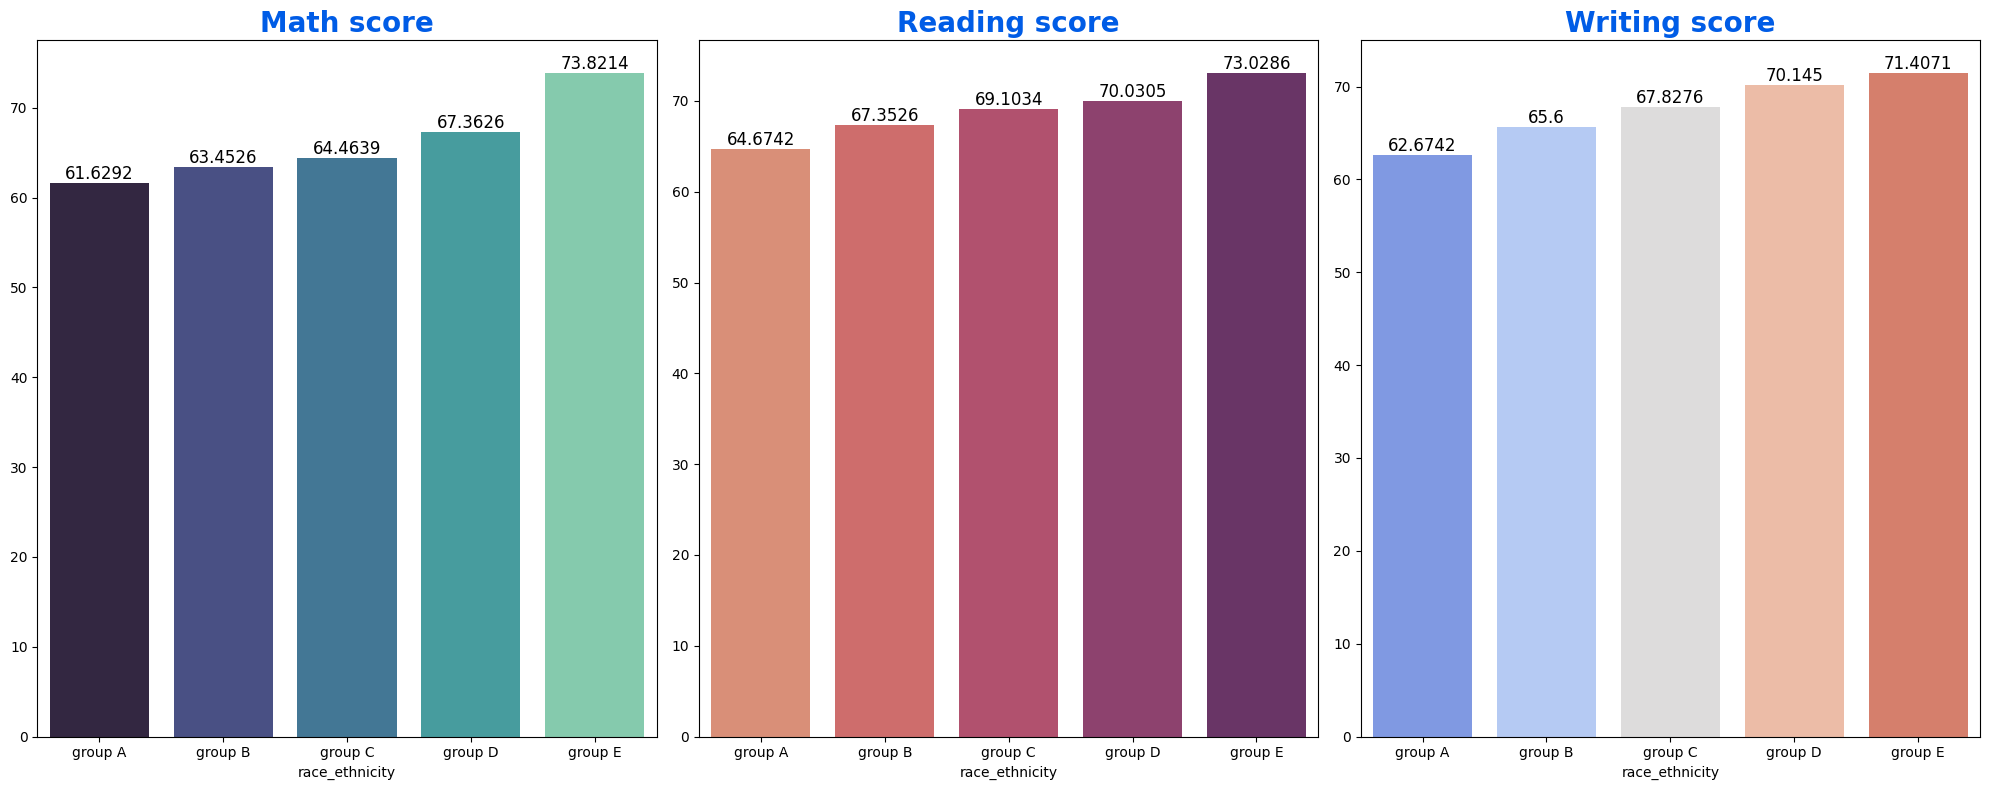

In [33]:
gp_data2 = df.groupby('race_ethnicity')
fig, ax = plt.subplots(1,3, figsize=(20,8))
sns.barplot(x = gp_data2['math_score'].mean().index, 
            y = gp_data2['math_score'].mean().values,
            palette = 'mako',
            ax = ax[0])
ax[0].set_title("Math score", color='#005ce6', size=20, weight='bold')

for container in ax[0].containers:
    ax[0].bar_label(container, color='black', size=12)

sns.barplot(x = gp_data2['reading_score'].mean().index, 
            y = gp_data2['reading_score'].mean().values,
            palette = 'flare',
            ax = ax[1])
ax[1].set_title('Reading score',color='#005ce6',size=20, weight='bold')

for container in ax[1].containers:
    ax[1].bar_label(container, color='black', size=12)

sns.barplot(x = gp_data2['writing_score'].mean().index, 
            y = gp_data2['writing_score'].mean().values,
            palette = 'coolwarm',
            ax = ax[2])
ax[2].set_title('Writing score',color='#005ce6',size=20, weight='bold')

for container in ax[2].containers:
    ax[2].bar_label(container, color='black', size=12)

plt.tight_layout()
plt.show()

#### Insights 
- Group E students have scored the highest marks. 
- Group A students have scored the lowest marks. 
- Students from a lower Socioeconomic status have a lower avg in all course subjects

#### 4.4.3 PARENTAL LEVEL OF EDUCATION COLUMN
- What is educational background of student's parent ?
- Is parental education has any impact on student's performance ?

#### UNIVARIATE ANALYSIS ( What is educational background of student's parent ? )

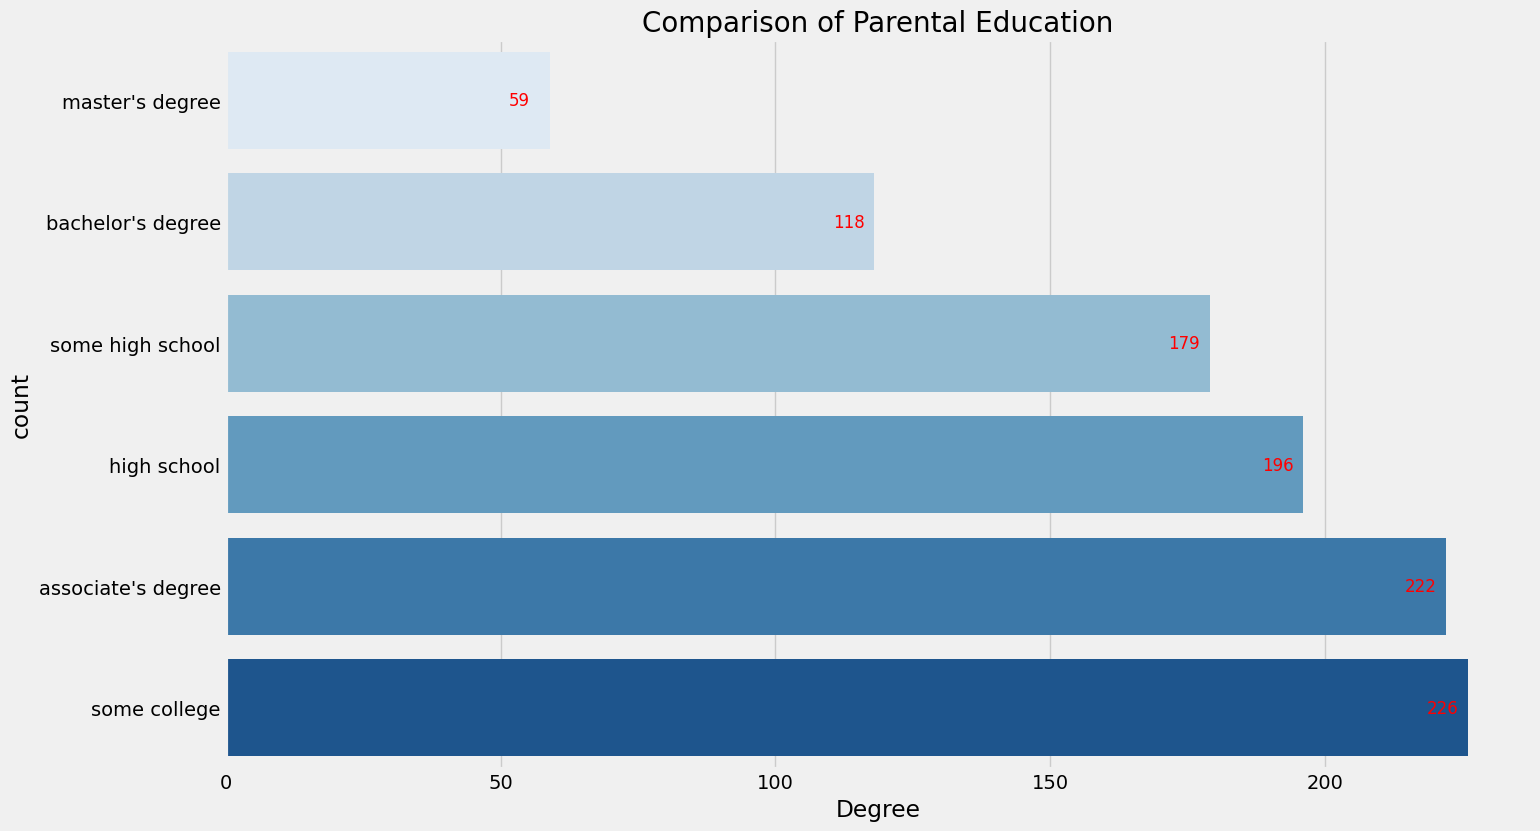

In [34]:
plt.rcParams['figure.figsize'] = (15, 9)
plt.style.use('fivethirtyeight')
order = df['parental_level_of_education'].value_counts(ascending=True).index
ax = sns.countplot(df['parental_level_of_education'], palette='Blues', order=order)

for container in ax.containers:
    ax.bar_label(container, size=12, color='red', padding=-30)

plt.title('Comparison of Parental Education', fontweight = 30, fontsize = 20)
plt.xlabel('Degree')
plt.ylabel('count')
plt.show()

#### Insights 
- Largest number of parents are from some college.

#### BIVARIATE ANALYSIS ( Is parental education has any impact on student's performance ? )

In [35]:
gp_data3 = df.groupby('parental_level_of_education').mean(numeric_only=True) \
            [['math_score','reading_score','writing_score']]
gp_data3

,math_score,reading_score,writing_score
parental_level_of_education,,,
associate's degree,67.882883,70.927928,69.896396
bachelor's degree,69.389831,73.000000,73.381356
high school,62.137755,64.704082,62.448980
master's degree,69.745763,75.372881,75.677966
some college,67.128319,69.460177,68.840708
some high school,63.497207,66.938547,64.888268


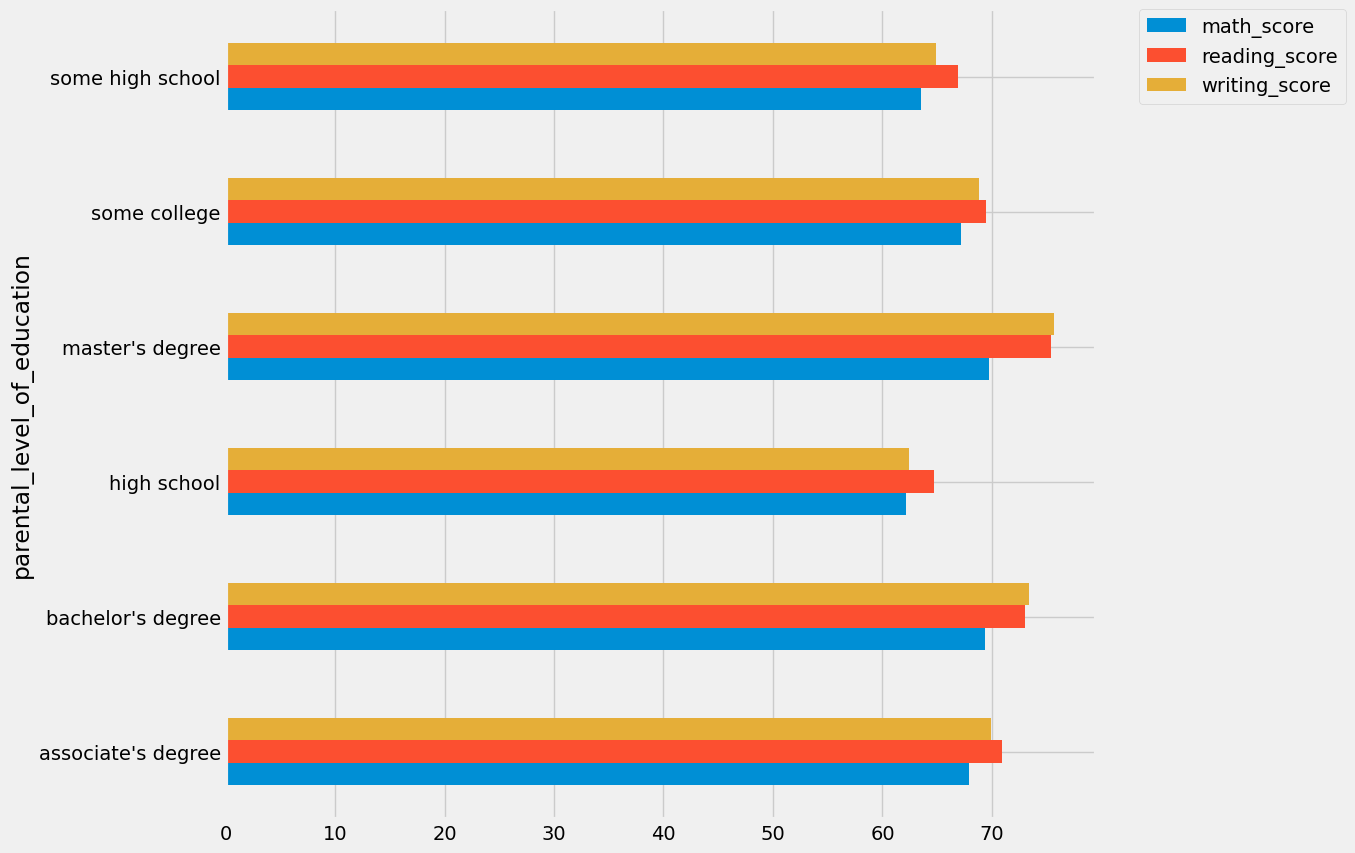

In [36]:
gp_data3.plot(kind='barh', figsize=(10,10))
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.show()

#### Insights 
- The score of student whose parents possess master and bachelor level education are higher than others.

#### 4.4.4 LUNCH COLUMN 
- Which type of lunch is most common amoung students ?
- What is the effect of lunch type on test results?


#### UNIVARIATE ANALYSIS ( Which type of lunch is most common amoung students ? )

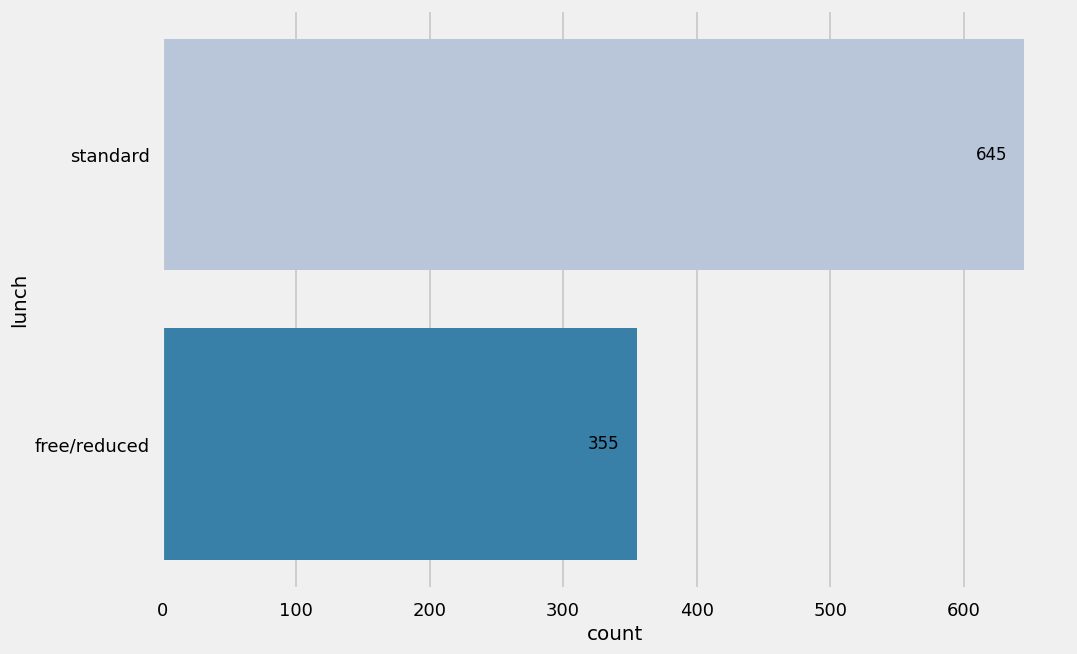

In [37]:
plt.rcParams['figure.figsize'] = (15, 9)
plt.style.use('seaborn-v0_8-talk')
x = sns.countplot(df['lunch'], palette='PuBu')
for container in x.containers:
    x.bar_label(container, size=12, padding=-35)
plt.show()

#### Insights 
- Students being served Standard lunch was more than free lunch

#### BIVARIATE ANALYSIS (  Is lunch type intake has any impact on student's performance ? )

[]

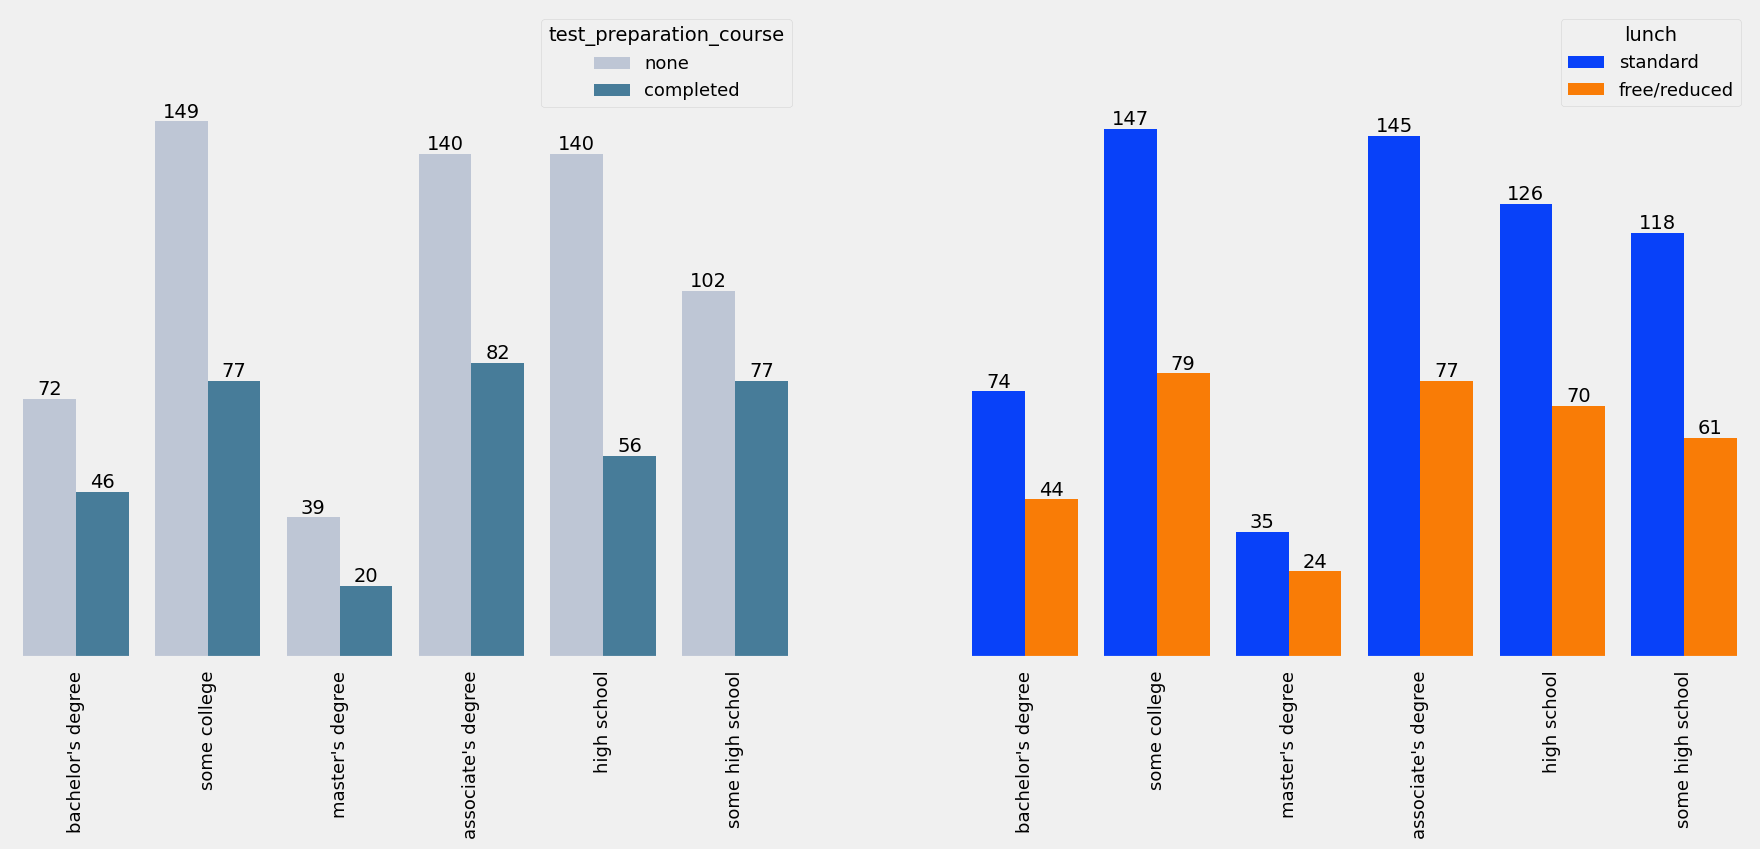

In [38]:
fig, ax = plt.subplots(1, 2, figsize=(20,8))
sns.countplot(data = df, 
              x = df['parental_level_of_education'], 
              palette = 'PuBu', 
              hue = 'test_preparation_course', 
              saturation = 0.55, 
              ax = ax[0])
for container in ax[0].containers:
    ax[0].bar_label(container)

sns.countplot(data = df, 
              x = df['parental_level_of_education'],
              palette = 'bright',
              hue = 'lunch',
              saturation = 0.95,
              ax = ax[1])
for container in ax[1].containers:
    ax[1].bar_label(container)
    
ax[0].set_ylim(0, 180)
ax[0].tick_params(axis='x', labelrotation=90)
ax[0].set_xlabel(None)
ax[0].set_ylabel(None)
ax[0].set_yticks([])
ax[1].set_ylim(0, 180)
ax[1].tick_params(axis='x', labelrotation=90)
ax[1].set_xlabel(None)
ax[1].set_ylabel(None)
ax[1].set_yticks([])

#### Insights 
- Students who get Standard Lunch tend to perform better than students who got free/reduced lunch

#### 4.4.5 TEST PREPARATION COURSE COLUMN 
- Which type of lunch is most common amoung students ?
- Is Test prepration course has any impact on student's performance ?

#### BIVARIATE ANALYSIS ( Is Test prepration course has any impact on student's performance ? )

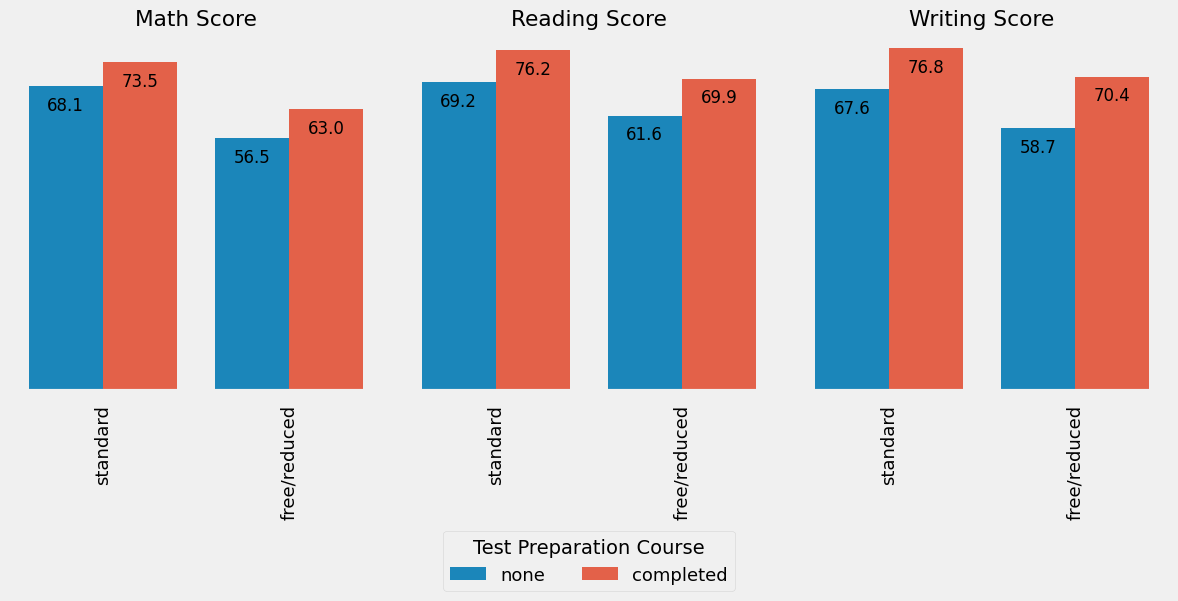

In [62]:
fig, axs = plt.subplots(1, 3, figsize=(12, 6))

sns.barplot(data=df, x='lunch', y='math_score', hue='test_preparation_course', errorbar=None, ax=axs[0])
sns.barplot(data=df, x='lunch', y='reading_score', hue='test_preparation_course', errorbar=None, ax=axs[1])
sns.barplot(data=df, x='lunch', y='writing_score', hue='test_preparation_course', errorbar=None, ax=axs[2])

for ax in axs:
    # Remove legends from each subplot
    ax.get_legend().remove()
    for container in ax.containers:
        ax.bar_label(container, size=12, padding=-20, fmt='%.1f')

# Create ONE legend for the whole figure
handles, labels = axs[0].get_legend_handles_labels()

fig.legend(handles,
           labels,
           title = "Test Preparation Course",
           loc = "lower center",           # Position
           ncol = 2,                       # Two columns
           bbox_to_anchor = (0.5, -0.02))  # Move below the plots

# Format each subplot
titles = ['Math Score', 'Reading Score', 'Writing Score']

for ax, title in zip(axs, titles):
    ax.set_title(title)
    ax.set_ylim(0, 80)
    ax.tick_params(axis='x', labelrotation=90)
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_yticks([])

# Leave room for the legend
plt.tight_layout(rect=[0, 0.08, 1, 1])

plt.show()

#### Insights  
- Students who have completed the Test Prepration Course have scores higher in all three categories than those who haven't taken the course

#### 4.4.6 CHECKING OUTLIERS

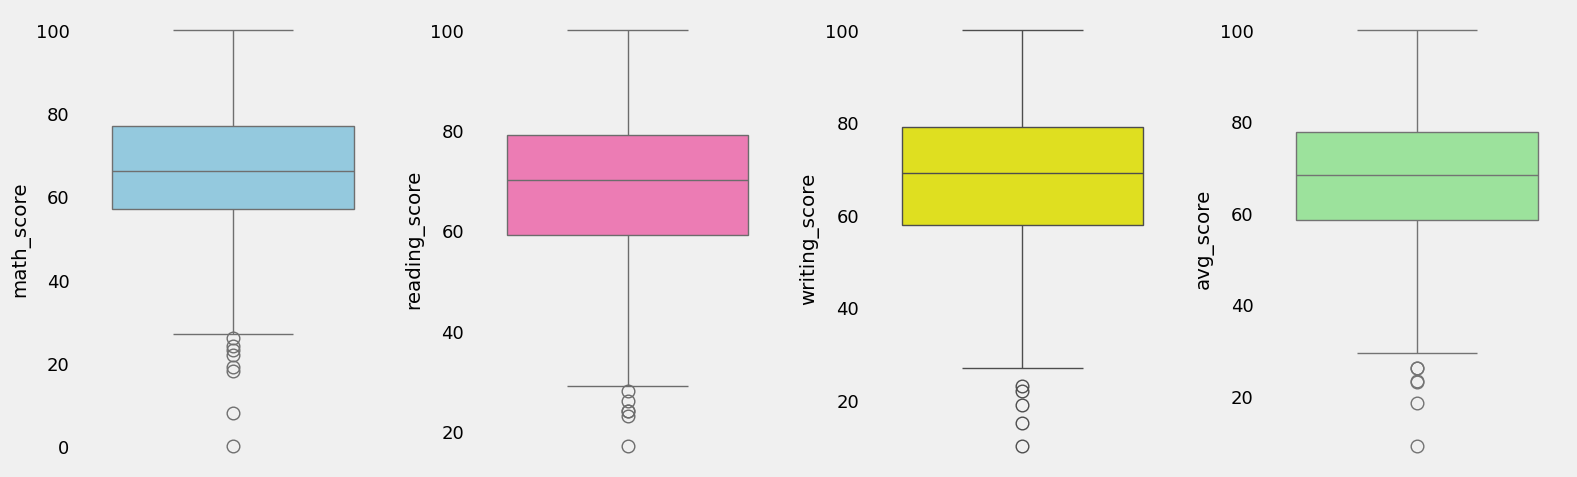

In [76]:
cols = ['math_score','reading_score','writing_score','avg_score']
colors = ['skyblue','hotpink','yellow','lightgreen']
splots = [141,142,143,144]
plt.subplots(1, 4, figsize=(16,5))
for col, splot, color in zip(cols, splots, colors):
    plt.subplot(splot)
    plt.grid(None)
    sns.boxplot(df[col],color=color)

plt.tight_layout()
plt.show()

#### 4.4.7 MUTIVARIATE ANALYSIS USING PAIRPLOT

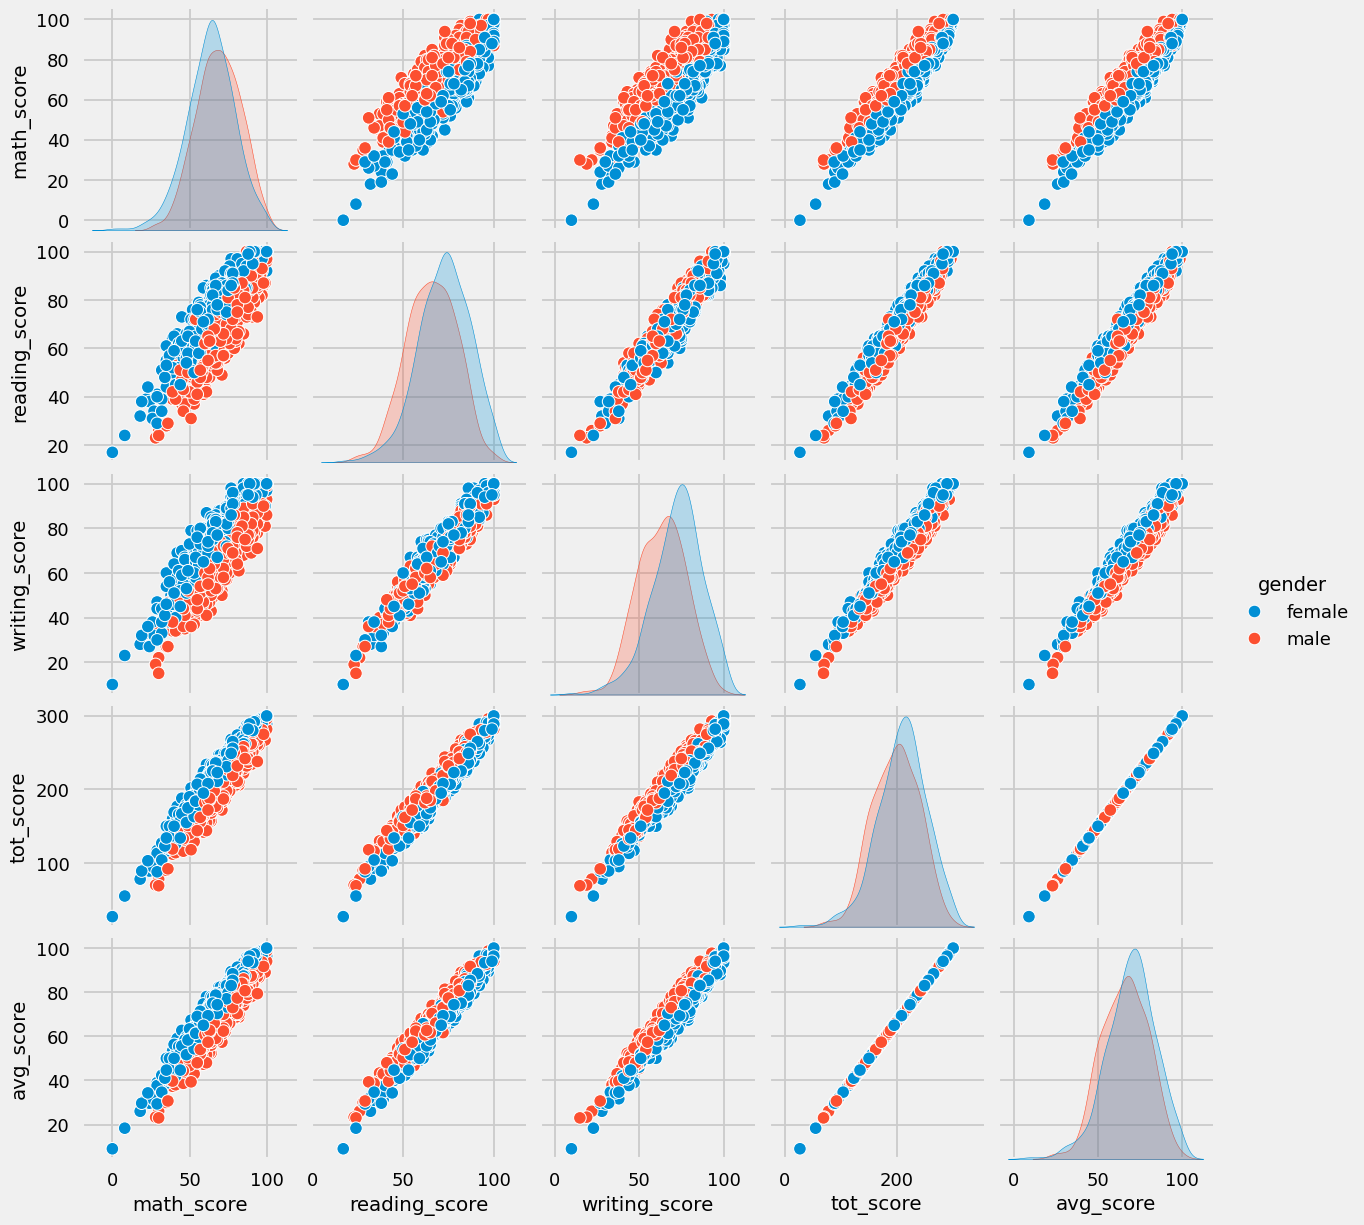

In [77]:
sns.pairplot(df, hue='gender')
plt.show()

#### Insights
- From the above plot it is clear that all the scores increase linearly with each other.

### 5. Conclusions
- Student's Performance is related with lunch, race, parental level education
- Females lead in pass percentage and also are top-scorers
- Student's Performance is not much related with test preparation course
- Finishing preparation course is benefitial.